2413998 - Pratik Shrestha

**3.2 Task-1: Implementation of MCP Neurons**
1. Design a MCP Neuron for ”AND” Boolean Functions and ”OR”Boolean Functions with two inputs.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


"AND" Gate using MCP Neuron

In [3]:
def MCP_Neurons_AND(X1, X2, T):
    assert len(X1) == len(X2)

    state_neuron = []

    for i in range(len(X1)):
        summation = X1[i] + X2[i]

        if summation >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


# Example
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2

result = MCP_Neurons_AND(X1, X2, T)
print("AND Output:", result)

AND Output: [0, 0, 0, 1]


"OR" Gate

In [4]:
def MCP_Neurons_OR(X1, X2, T):
    # Ensure both inputs are same length
    assert len(X1) == len(X2)

    state_neuron = []  # Store results

    # Loop through inputs
    for i in range(len(X1)):
        # Compute sum of inputs
        summation = X1[i] + X2[i]

        # Apply threshold condition
        if summation >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


# Example usage
T = 1  # Threshold for OR gate

result_or = MCP_Neurons_OR(X1, X2, T)
print("OR Output:", result_or)

OR Output: [0, 1, 1, 1]


**3.2.1**

**Question- 1: List out all the limitations of MCP- Neurons.**

Ans:
*   Cannot learn (no training mechanism)
*   Cannot handle non-linear problems
*   Cannot solve XOR problem
*   Very simple (only binary inputs/outputs)





**Question- 2: Think if you can develop a logic to solve for XOR function using MCP Neuron.**

Ans: MCP Neuron can not solve for XOR function


**4.3 Task-2: Perceptron Algorithm for 0 vs 1 Classification.**

In [5]:
#Load Dataset
import pandas as pd
import numpy as np

# Load dataset (update path if needed)
df_0_1 = pd.read_csv("/content/drive/MyDrive/AI and Machine Learning/mnist_3_and_5.csv")

# Separate features (pixels) and labels
X = df_0_1.drop(columns=["label"]).values  # 784 features (28x28 image)
y = df_0_1["label"].values  # Labels (0 or 1)

# Print shapes
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (2741, 784)
Label vector shape: (2741,)


**Question- 1: What does the shape of X represent?**

Ans: The shape of X represents Number of samples × number of features.

**Question- 2: What does the shape of Y represent?**

Ans: The shape of Y represents Number of labels (one per image).

In [6]:
# Initialize weights with zeros (one weight per pixel)
weights = np.zeros(X.shape[1])
# Initialize bias
bias = 0
# Learning rate controls update step size
learning_rate = 0.1
# Number of iterations
epochs = 100

**Question- 3: What does the weights array represent in this context?**

Ans: Each weight corresponds to one pixel feature. It determines importance of that pixel

**Question- 4: Why are we initializing the weights to zero? What effect could this
have on the training process?**

Ans: We are initializing the weights to zero because 0 is a simple starting point and models learn form scratch. On the training data it could effect slow learning.

In [7]:
#Decision Function
def decision_function(X, weights, bias):
    """
    Computes predictions using trained weights and bias
    """

    # Compute weighted sum (z = wx + b)
    predictions = np.dot(X, weights) + bias

    # Apply step activation function
    # If z >= 0 → class 1, else class 0
    y_pred_all = np.where(predictions >= 0, 1, 0)

    return y_pred_all

In [8]:
#Training the Perceptron
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train perceptron using learning algorithm
    """

    # Loop over epochs
    for epoch in range(epochs):
        correct = 0  # Count correct predictions

        # Loop through each training sample
        for i in range(len(X)):

            # Step 1: Compute weighted sum
            output = np.dot(X[i], weights) + bias

            # Step 2: Apply step function
            y_pred = 1 if output >= 0 else 0

            # Step 3: Check prediction
            if y_pred == y[i]:
                correct += 1  # Correct prediction
            else:
                # Step 4: Update weights if wrong
                weights = weights + learning_rate * (y[i] - y_pred) * X[i]

                # Update bias
                bias = bias + learning_rate * (y[i] - y_pred)

        # Calculate accuracy for this epoch
        accuracy = correct / len(X)

    return weights, bias, accuracy

**Question-5: What is the purpose of the output=np.dot(X[i],weights)+biasline?**

Ans: Computes weighted sum (decision boundary).

**Question- 6: What happens when the prediction is wrong? How are the weights and
bias updated?**

Ans: When prediction is wrong we update weights as below:

weights = weights + η(y − y_pred)X

bias = bias + η(y − y_pred)

**Question-7: Why is the final accuracy important, and what do you expect it to be?**

Ans: The final accuracy is important because it shows the the model performed/learned overall.I expect it to be high which is close to 1.

In [9]:
#Train Model
# Train perceptron
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

# Print final accuracy
print("Final Accuracy:", accuracy)

Final Accuracy: 0.0


Final Accuracy: 0.0


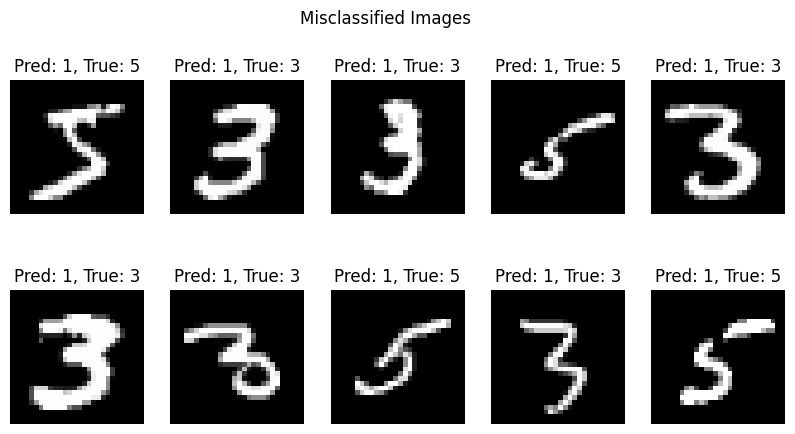

In [10]:
#Misclassified Images
# Compute predictions
predictions = np.dot(X, weights) + bias

# Apply step function
y_pred = np.where(predictions >= 0, 1, 0)

# Calculate accuracy
final_accuracy = np.mean(y_pred == y)
print("Final Accuracy:", final_accuracy)

# Get indices where prediction != actual
misclassified_idx = np.where(y_pred != y)[0]

# Visualize misclassified images
import matplotlib.pyplot as plt

if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))

    # Show first 10 misclassified images
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")

    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

**Question-8: What does misclassified_idx store, and how is it used in this code?**

Ans: It stores indices of wrongly classified images.

**Question- 9: How do you interpret the result if the output is ”All images were
correctly classified!”?**

Ans: It means model achieved 100% accuracy and data is perfectly separable.

**4.4 Task-3: Perceptron Algorithm for 3 vs 5 Classification**

In [11]:
# Load dataset for digits 3 and 5
df_3_5 = pd.read_csv("/content/drive/MyDrive/AI and Machine Learning/mnist_3_and_5.csv")

# Extract features and labels
X = df_3_5.drop(columns=["label"]).values
y = df_3_5["label"].values

# Initialize weights and bias
weights = np.zeros(X.shape[1])
bias = 0

# Train perceptron
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

print("Final Accuracy (3 vs 5):", accuracy)

Final Accuracy (3 vs 5): 0.0


Visualization of Misclassified Images (3 vs 5)

Final Accuracy: 0.0000


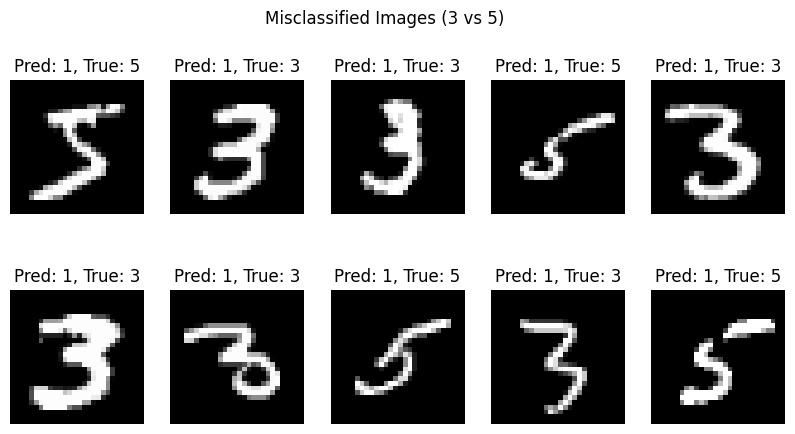

In [12]:
# Compute predictions using trained weights and bias
predictions = np.dot(X, weights) + bias

# Apply step function to convert into class labels (0 or 1)
y_pred = np.where(predictions >= 0, 1, 0)

# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Find indices where prediction is incorrect
misclassified_idx = np.where(y_pred != y)[0]

import matplotlib.pyplot as plt

# Check if there are misclassified images
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))

    # Display first 10 misclassified images
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")

    plt.suptitle("Misclassified Images (3 vs 5)")
    plt.show()

else:
    print("All images were correctly classified!")

The perceptron model resulted in 0% accuracy, incorrectly classifying every image. It consistently predicted a single class for all inputs, indicating that it was unable to learn from the dataset. This likely happened because the digits 3 and 5 are not linearly separable and share similar visual patterns, which makes them challenging for a basic perceptron to distinguish.

